In [1]:
import random
import numpy as np
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Generador de laberinto

In [2]:
# constantes
CAMINO = 0
PARED = 1
ORIGEN = 2
META = 3
VISITADO = 4
SOLUCION = 5

# Paleta de colores: [Blanco, Negro, Azul, Rojo, Celeste, Amarillo]
colores_laberinto = ListedColormap(['#FFFFFF', '#1A1A1A', '#007BFF', '#DC3545', '#AED6F1', '#F1C40F'])

# parametros
sys.setrecursionlimit(5000)
probabilidad_romper_pared=0.05
ANCHO = 200
ALTO = 200

In [3]:
"""
    Genera una matriz bidimensional que representa un laberinto aleatorio
    utilizando búsqueda en profundidad (DFS) con backtracking.

    Args:
        ancho (int): El número de columnas (se ajustará a impar).
        alto (int): El número de filas (se ajustará a impar).
        probabilidad_romper (float): probabilidad [0 a 1] de romper una pared en cada casilla

    Returns:
        list[list[int]]: Matriz con valores CAMINO, PARED, ORIGEN y META.
"""
def generar_laberinto(ancho, alto, probabilidad_romper): 
    if ancho % 2 == 0: ancho += 1
    if alto % 2 == 0: alto += 1

    # Inicializar lleno de Paredes
    laberinto = [[PARED for _ in range(ancho)] for _ in range(alto)]

    def excavar(x, y):
        laberinto[y][x] = CAMINO
        direcciones = [(0, -2), (2, 0), (0, 2), (-2, 0)]
        random.shuffle(direcciones)

        for dx, dy in direcciones:
            nx, ny = x + dx, y + dy
            if 1 <= nx < ancho - 1 and 1 <= ny < alto - 1 and laberinto[ny][nx] == PARED:
                laberinto[y + dy // 2][x + dx // 2] = CAMINO
                excavar(nx, ny)

    # 1. Generar laberinto base (Perfecto)
    inicio_x = random.randrange(1, ancho, 2)
    inicio_y = random.randrange(1, alto, 2)
    excavar(inicio_x, inicio_y)

    # 2. Romper paredes aleatoriamente para crear ciclos (Caminos múltiples)
    for y in range(1, alto - 1):
        for x in range(1, ancho - 1):
            if laberinto[y][x] == PARED:
                # Solo romper si la pared separa dos caminos (evita áreas abiertas feas)
                # Revisar si hay caminos a los lados (horizontal o vertical)
                es_pared_horizontal = (laberinto[y][x-1] == CAMINO and laberinto[y][x+1] == CAMINO)
                es_pared_vertical = (laberinto[y-1][x] == CAMINO and laberinto[y+1][x] == CAMINO)
                
                if (es_pared_horizontal or es_pared_vertical) and random.random() < probabilidad_romper:
                    laberinto[y][x] = CAMINO

    # 3. Establecer Puntos de Interés
    laberinto[1][0] = ORIGEN                  
    laberinto[alto - 2][ancho - 1] = META   

    return laberinto


"""
    Usa Matplotlib para renderizar la matriz del laberinto con colores personalizados y leyenda.
"""
def dibujar_laberinto_grafico(laberinto):
    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # IMPORTANTE: vmax=5 para que reconozca los valores de VISITADO y SOLUCION
    # vmin=0 (Camino) hasta vmax=5 (Solución)
    img = ax.imshow(laberinto, cmap=colores_laberinto, interpolation='nearest', vmin=0, vmax=5)
    
    ax.axis('off')
    plt.title("Laberinto", fontsize=18, fontweight='bold', pad=20)
    
    # --- Leyenda Actualizada con 6 estados ---
    parches = [
        mpatches.Patch(color='#1A1A1A', label='Pared'),
        mpatches.Patch(color='#FFFFFF', label='Camino', ec='#CCCCCC'),
        mpatches.Patch(color='#007BFF', label='Origen'),
        mpatches.Patch(color='#DC3545', label='Meta'),
        mpatches.Patch(color='#AED6F1', label='Explorado'),
        mpatches.Patch(color='#F1C40F', label='Solución')
    ]
    
    ax.legend(handles=parches, 
              loc='upper center', 
              bbox_to_anchor=(0.5, -0.02),
              fancybox=True, 
              shadow=True, 
              ncol=3, # En dos filas de 3 queda más ordenado
              fontsize=11)
    
    plt.tight_layout()
    plt.show()

"""
    Encuentra las coordenadas (f, c) de un valor específico.
"""
def obtener_posicion(laberinto, valor):
    
    for f, fila in enumerate(laberinto):
        for c, celda in enumerate(fila):
            if celda == valor:
                return (f, c)
    return None

Generando y dibujando laberinto de 200x200...


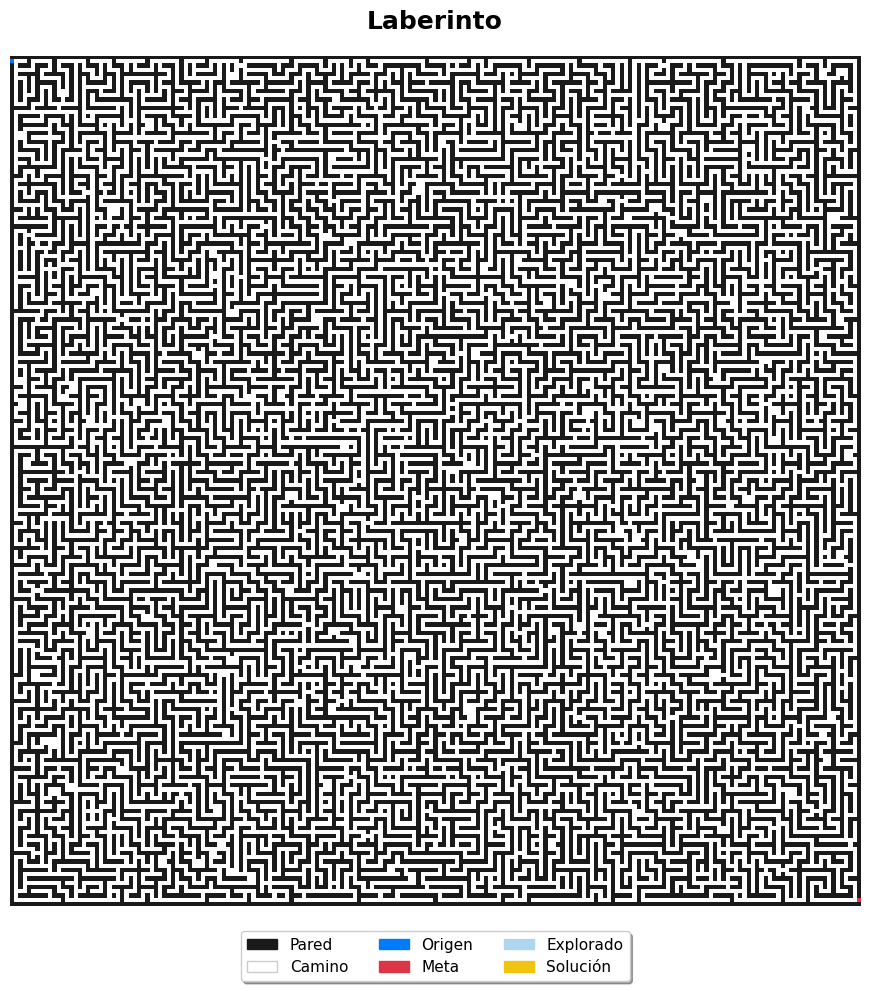

In [4]:
print(f"Generando y dibujando laberinto de {ANCHO}x{ALTO}...")
laberinto = generar_laberinto(ANCHO, ALTO, probabilidad_romper_pared)
    
# Llamamos a la nueva función gráfica
dibujar_laberinto_grafico(laberinto)

# Transformar el algoritmo a un espacio de grafos

In [5]:
"""
    Convierte la matriz del laberinto en un diccionario de adyacencia.
    Solo conecta celdas que sean CAMINO, ORIGEN o META.
"""
def construir_grafo(laberinto):
    
    filas = len(laberinto)
    columnas = len(laberinto[0])
    laberinto_grafos = {}

    # Definir qué valores son transitables
    transitables = {CAMINO, ORIGEN, META}

    for f in range(filas):
        for c in range(columnas):
            # Si la celda actual es transitable, la agregamos al grafo
            if laberinto[f][c] in transitables:
                nodo_actual = (f, c)
                laberinto_grafos[nodo_actual] = []

                # Revisar las 4 direcciones adyacentes (Arriba, Abajo, Izquierda, Derecha)
                for df, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nf, nc = f + df, c + dc

                    # Verificar que el vecino esté dentro de la matriz y sea transitable
                    if 0 <= nf < filas and 0 <= nc < columnas:
                        if laberinto[nf][nc] in transitables:
                            # Añadir el vecino a la lista de adyacencia
                            laberinto_grafos[nodo_actual].append((nf, nc))
    
    return laberinto_grafos

grafo = construir_grafo(laberinto)
print(f"Grafo generado con {len(grafo)} nodos transitables.")        

Grafo generado con 20771 nodos transitables.


# Solucionar el laberinto

In [10]:
from collections import deque
import heapq
import time

In [11]:
def resolver_con_rastreo(algoritmo, grafo, inicio, fin):
    visitados_orden = []
    padres = {inicio: None}
    
    if algoritmo == "Dijkstra":
        # Usamos Priority Queue. Formato: (distancia_acumulada, nodo_actual)
        pq = [(0, inicio)]
        distancias = {inicio: 0}
        visitados_set = set()

        while pq:
            dist_actual, actual = heapq.heappop(pq)
            
            if actual == fin: break
            if actual in visitados_set: continue
            
            visitados_set.add(actual)
            visitados_orden.append(actual)

            for vecino in grafo.get(actual, []):
                nueva_distancia = dist_actual + 1 # Costo uniforme de 1 en laberintos
                if vecino not in distancias or nueva_distancia < distancias[vecino]:
                    distancias[vecino] = nueva_distancia
                    padres[vecino] = actual
                    heapq.heappush(pq, (nueva_distancia, vecino))

    elif algoritmo == "A*":
        pq = [(0, inicio)]
        costo_hasta_ahora = {inicio: 0}
        visitados_set = set()
        
        while pq:
            _, actual = heapq.heappop(pq)
            if actual == fin: break
            if actual not in visitados_set:
                visitados_set.add(actual)
                visitados_orden.append(actual)
                for vecino in grafo.get(actual, []):
                    nuevo_costo = costo_hasta_ahora[actual] + 1
                    if vecino not in costo_hasta_ahora or nuevo_costo < costo_hasta_ahora[vecino]:
                        costo_hasta_ahora[vecino] = nuevo_costo
                        prioridad = nuevo_costo + heuristica(fin, vecino)
                        heapq.heappush(pq, (prioridad, vecino))
                        padres[vecino] = actual

    elif algoritmo == "BFS":
        cola = deque([inicio])
        visitados_set = {inicio}
        while cola:
            actual = cola.popleft()
            visitados_orden.append(actual)
            if actual == fin: break
            for vecino in grafo.get(actual, []):
                if vecino not in visitados_set:
                    visitados_set.add(vecino)
                    padres[vecino] = actual
                    cola.append(vecino)

    elif algoritmo == "DFS":
        pila = [inicio]
        visitados_set = set()
        while pila:
            actual = pila.pop()
            if actual == fin: break
            if actual not in visitados_set:
                visitados_set.add(actual)
                visitados_orden.append(actual)
                for vecino in grafo.get(actual, []):
                    if vecino not in visitados_set:
                        padres[vecino] = actual
                        pila.append(vecino)

    return reconstruir_camino(padres, inicio, fin), visitados_orden

# Actualiza también la lista de algoritmos para graficar 4 en lugar de 3
def comparar_algoritmos(laberinto, grafo):
    inicio = obtener_posicion(laberinto, ORIGEN)
    fin = obtener_posicion(laberinto, META)
    algoritmos = ["DFS", "BFS", "Dijkstra", "A*"] # Se añade Dijkstra
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 6)) # Cambiado a 4 subplots
    
    for i, nombre in enumerate(algoritmos):
        start_time = time.perf_counter()
        camino, visitados = resolver_con_rastreo(nombre, grafo, inicio, fin)
        end_time = time.perf_counter()
        
        capa_visual = np.array(laberinto)
        for f, c in visitados:
            if capa_visual[f][c] == CAMINO: capa_visual[f][c] = VISITADO
        for f, c in camino:
            if capa_visual[f][c] not in [ORIGEN, META]: capa_visual[f][c] = SOLUCION

        axes[i].imshow(capa_visual, cmap=colores_laberinto, interpolation='nearest', vmin=0, vmax=5)
        titulo = (f"{nombre}\nVisitados: {len(visitados)}\nPasos: {len(camino)}\n"
                  f"{end_time - start_time:.5f}s")
        axes[i].set_title(titulo, fontsize=10, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

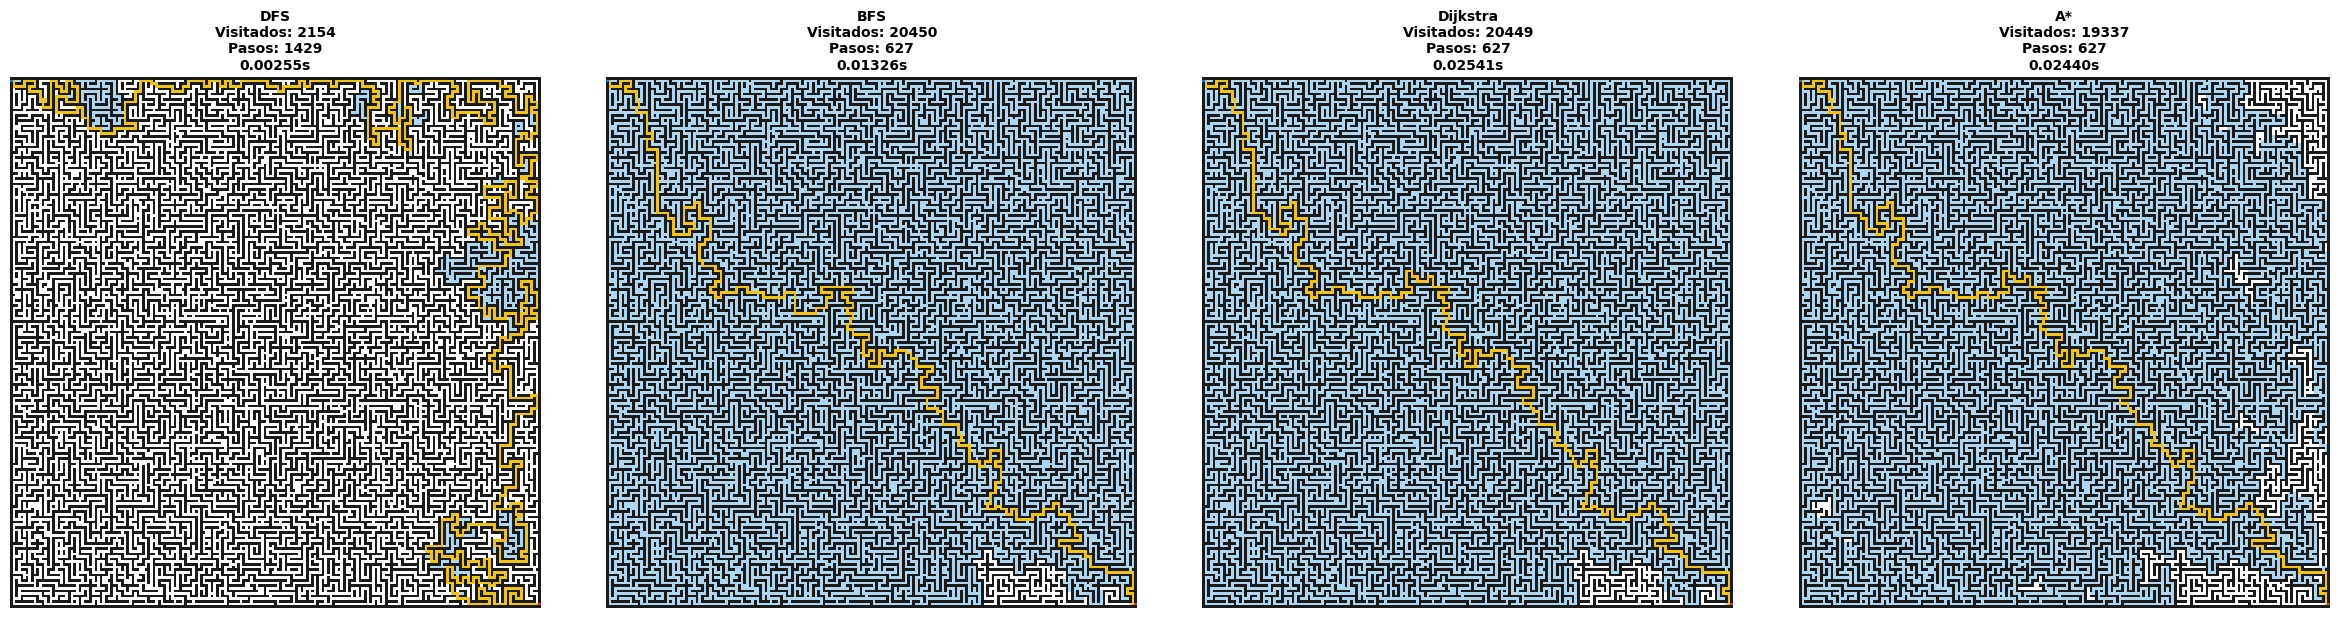

In [12]:
comparar_algoritmos(laberinto,grafo)